# Random Forests

Replication of Breiman (2001), *Random Forests*, Machine Learning 45.

A random forest is an ensemble of decision trees, each grown on a bootstrap sample with a
random subset of features considered at every split. The paper shows that this randomized
averaging sharply reduces the variance of a single tree and that the out-of-bag (OOB) error
is an unbiased estimate of generalization error that decreases as trees are added. We
reproduce both: the forest clearly outperforms a single deep tree, and the OOB error falls
and stabilizes with the number of trees.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
X, y = make_classification(n_samples=2000, n_features=20, n_informative=8,
                           n_redundant=4, n_classes=2, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
print("train", Xtr.shape, "test", Xte.shape)

train (1400, 20) test (600, 20)


In [3]:
# Single fully grown tree vs a random forest.
tree = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
forest = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=0).fit(Xtr, ytr)
print(f"single decision tree test accuracy: {tree.score(Xte, yte)*100:.2f}%")
print(f"random forest       test accuracy: {forest.score(Xte, yte)*100:.2f}%")
print(f"forest OOB-score estimate          : {forest.oob_score_*100:.2f}%")

single decision tree test accuracy: 88.00%


random forest       test accuracy: 92.17%
forest OOB-score estimate          : 91.14%


In [4]:
# OOB error as a function of the number of trees.
errs = []
ns = list(range(1, 151, 5))
for n in ns:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=0,
                                bootstrap=True).fit(Xtr, ytr)
    errs.append(1 - rf.oob_score_)
print(f"OOB error at  5 trees: {errs[0]:.3f}")
print(f"OOB error at 150 trees: {errs[-1]:.3f}")

OOB error at  5 trees: 0.389
OOB error at 150 trees: 0.089


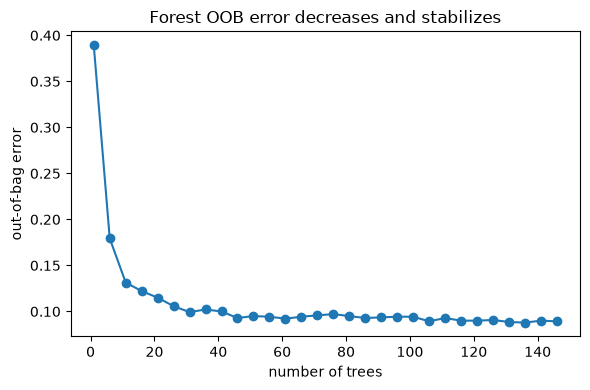

In [5]:
plt.figure(figsize=(6,4)); plt.plot(ns, errs, marker="o")
plt.xlabel("number of trees"); plt.ylabel("out-of-bag error")
plt.title("Forest OOB error decreases and stabilizes"); plt.tight_layout(); plt.show()